In [3]:
import os
os.chdir('/content/CSI5388-Group1-Project')

In [8]:
import sys
sys.path.append('/content/CSI5388-Group1-Project/src')
import data_preprocessing as dp
import pandas as pd

def load_dataset_colab(dataset_path):
    if "Mendeley" in dataset_path:
        df = pd.read_csv("/content/drive/MyDrive/CSI5388 A2/Phishing Detection Datasetm/Mendeley Dataset.csv")
        df = df.rename(columns={'Type': 'Label'})
    else:
        df = pd.read_csv("/content/drive/MyDrive/CSI5388 A2/Phishing Detection Datasetm/dataset_phishing.csv")
        df["Label"] = df["Label"].map({"legitimate": 0, "phishing": 1})
        df = df.drop(columns=["url"])
    return df

dp.load_dataset = load_dataset_colab

In [6]:
# Variance Threshold Feature Selection
import pandas as pd
from data_preprocessing import create_train_test_val_sets, get_processed_df
import joblib
import os
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [9]:
#Create test train splits
x_mendeley, y_mendeley = get_processed_df(r"..\data\raw\Mendeley Dataset.csv")
x_kaggle, y_kaggle= get_processed_df(r"..\data\raw\dataset_phishing.csv")

mendeley_sets = create_train_test_val_sets(x_mendeley,y_mendeley, label_col="Label", test_size=0.2, n_splits=5)
kaggle_sets = create_train_test_val_sets(x_kaggle,y_kaggle, label_col="Label", test_size=0.2, n_splits=5)

----------Processing None Dataset----------

Class Distribution:
Label
0    0.518415
1    0.481585
Name: proportion, dtype: float64
int64

Total Missing Values: 0
No categorical features to hash
Shape After Processing: (247950, 42)
True
----------Processing None Dataset----------

Class Distribution:
Label
0    0.5
1    0.5
Name: proportion, dtype: float64
int64

Total Missing Values: 0
No categorical features to hash
Shape After Processing: (11430, 88)
True
Train/validation/test split prepared: 210757 instances for training, 37193 instances for validation, 49590 instances for testing
Stratified 5-fold CV splits created.
Train/validation/test split prepared: 9715 instances for training, 1715 instances for validation, 2286 instances for testing
Stratified 5-fold CV splits created.


In [10]:
kaggle_sets["y_train"] = kaggle_sets["y_train"].astype(int)
kaggle_sets["y_val"] = kaggle_sets["y_val"].astype(int)
kaggle_sets["y_test"] = kaggle_sets["y_test"].astype(int)

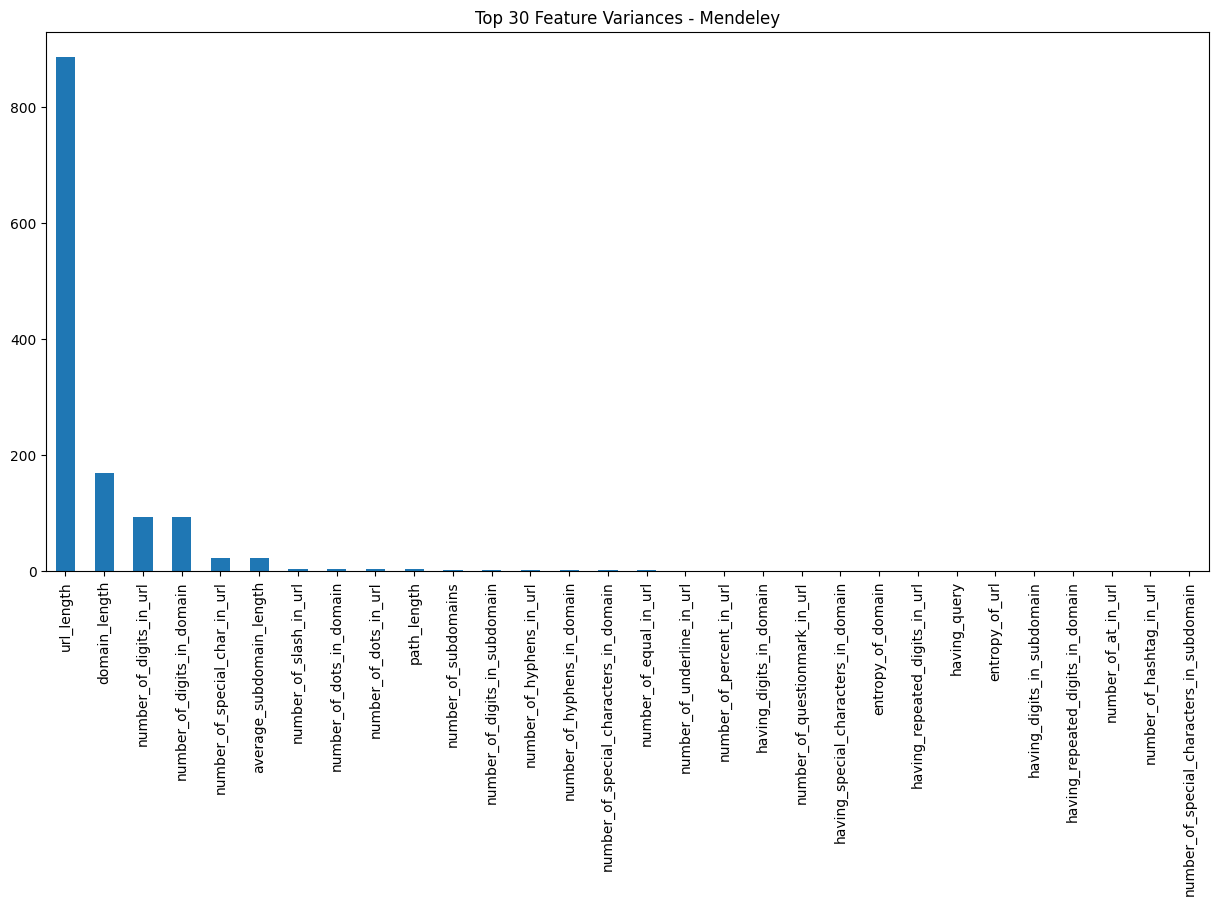

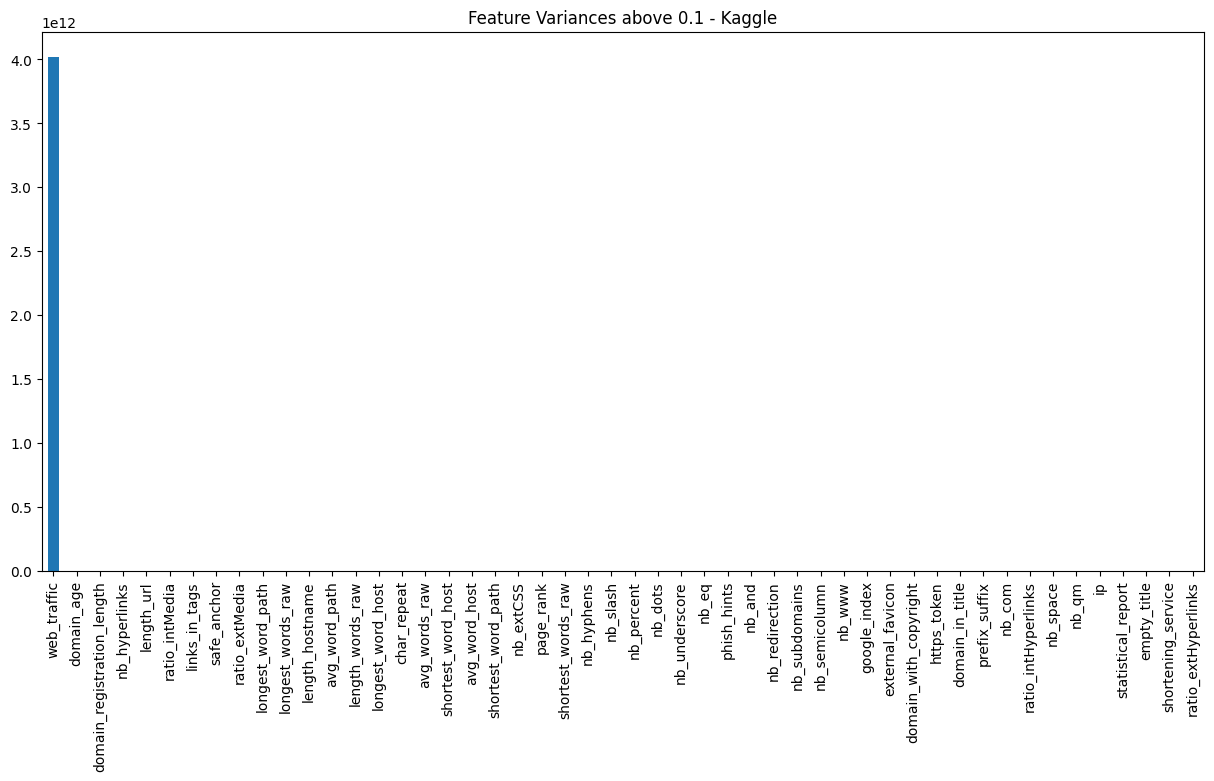

In [11]:
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt

# Mendeley - plot feature variances
variances_mendeley = mendeley_sets["x_train"].var()
variances_mendeley.sort_values(ascending=False).head(30).plot.bar(figsize=(15, 7))
plt.title("Top 30 Feature Variances - Mendeley")
plt.show()

# Kaggle - plot feature variances
variances_kaggle = kaggle_sets["x_train"].var()
variances_kaggle[variances_kaggle > 0.1].sort_values(ascending=False).plot.bar(figsize=(15, 7))
plt.title("Feature Variances above 0.1 - Kaggle")
plt.show()

In [14]:
import shutil
import os

os.makedirs('./models/phase_1', exist_ok=True)

# Copy models from the cloned repo
shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/xgboost_mendeley_no_fs.joblib', './models/phase_1/')
shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/xgboost_kaggle_no_fs.joblib', './models/phase_1/')
shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/logreg_mendeley_no_fs.joblib', './models/phase_1/')
shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/logreg_kaggle_no_fs.joblib', './models/phase_1/')
# shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/rf_mendeley_no_fs.joblib', './models/phase_1/')
# shutil.copy('/content/CSI5388-Group1-Project/src/models/phase_1/rf_kaggle_no_fs.joblib', './models/phase_1/')

print("Done!")

Done!


In [15]:
#import phase 1 models
xgb_mendeley = joblib.load('./models/phase_1/xgboost_mendeley_no_fs.joblib')
xgb_kaggle = joblib.load('./models/phase_1/xgboost_kaggle_no_fs.joblib')
logreg_mendeley = joblib.load('./models/phase_1/logreg_mendeley_no_fs.joblib')
logreg_kaggle = joblib.load('./models/phase_1/logreg_kaggle_no_fs.joblib')
# rf_mendeley = joblib.load('./models/phase_1/rf_mendeley_no_fs.joblib')
# rf_kaggle = joblib.load('./models/phase_1/rf_kaggle_no_fs.joblib')

In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score

def get_threshold_values(dataset, model, threshold_values, dataset_name, model_name):
    performance_history = []
    best_values = {"f1": 0, "threshold": 0}
    for threshold in threshold_values:
        selector = VarianceThreshold(threshold=threshold)
        selector.fit(dataset["x_train"])

        X_train_selected = selector.transform(dataset["x_train"])
        X_val_selected = selector.transform(dataset["x_val"])

        X_train_selected_names = dataset["x_train"].columns[selector.get_support()]

        model.fit(X_train_selected, dataset["y_train"])
        y_val_pred = model.predict(X_val_selected)
        score = f1_score(dataset["y_val"], y_val_pred)
        print("Model =", model_name, "threshold =", threshold, " f1_score =", score, " features =", X_train_selected.shape[1])

        if score > best_values["f1"]:
            best_values = {"f1": score, "threshold": threshold}

        performance_history.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'threshold': threshold,
            'num_features': X_train_selected.shape[1],
            'f1_Score': score,
            'Precision': precision_score(dataset["y_val"], y_val_pred),
            'Recall': recall_score(dataset["y_val"], y_val_pred),
            'Features': X_train_selected_names
        })
    return performance_history, best_values

vt_best_performance = []

threshold_values_mendeley = [0.01, 0.05, 0.1, 0.2, 0.5]
threshold_values_kaggle = [0.01, 0.05, 0.1, 0.2, 0.5]

print("=== Mendeley Results ===")
performance, best_mendeley_xgb = get_threshold_values(mendeley_sets, xgb_mendeley, threshold_values_mendeley, "Mendeley", 'XGBoost')
vt_best_performance += performance
# performance, best_mendeley_logreg = get_threshold_values(mendeley_sets, logreg_mendeley, threshold_values_mendeley, "Mendeley", 'LogReg')
# vt_best_performance += performance
# performance, best_mendeley_rf = get_threshold_values(mendeley_sets, rf_mendeley, threshold_values_mendeley, "Mendeley", 'RandomForest')
# vt_best_performance += performance

print("=== Kaggle Results ===")
performance, best_kaggle_xgb = get_threshold_values(kaggle_sets, xgb_kaggle, threshold_values_kaggle, "Kaggle", 'XGBoost')
vt_best_performance += performance
# performance, best_kaggle_logreg = get_threshold_values(kaggle_sets, logreg_kaggle, threshold_values_kaggle, "Kaggle", 'LogReg')
# vt_best_performance += performance
# performance, best_kaggle_rf = get_threshold_values(kaggle_sets, rf_kaggle, threshold_values_kaggle, "Kaggle", 'RandomForest')
# vt_best_performance += performance

performance_df = pd.DataFrame(vt_best_performance)
os.makedirs("../results/phase_2", exist_ok=True)
performance_df.to_csv("../results/phase_2/vt_feature_selection_results.csv", index=False)
print("\nResults saved to '../results/phase_2/vt_feature_selection_results.csv'")

=== Mendeley Results ===
Model = XGBoost threshold = 0.01  f1_score = 0.9433106575963719  features = 27
Model = XGBoost threshold = 0.05  f1_score = 0.9433106575963719  features = 27
Model = XGBoost threshold = 0.1  f1_score = 0.9437602860223597  features = 25
Model = XGBoost threshold = 0.2  f1_score = 0.927796184165429  features = 20
Model = XGBoost threshold = 0.5  f1_score = 0.9266340849981423  features = 16
=== Kaggle Results ===
Model = XGBoost threshold = 0.01  f1_score = 0.9668797210923882  features = 65
Model = XGBoost threshold = 0.05  f1_score = 0.9668797210923882  features = 57
Model = XGBoost threshold = 0.1  f1_score = 0.9675550405561993  features = 50
Model = XGBoost threshold = 0.2  f1_score = 0.9692396982008126  features = 39
Model = XGBoost threshold = 0.5  f1_score = 0.9616724738675958  features = 31

Results saved to '../results/phase_2/vt_feature_selection_results.csv'


In [19]:
#import phase 1 models again so we get fresh untrained models
xgb_mendeley = joblib.load('./models/phase_1/xgboost_mendeley_no_fs.joblib')
xgb_kaggle = joblib.load('./models/phase_1/xgboost_kaggle_no_fs.joblib')
# logreg_mendeley = joblib.load('./models/phase_1/logreg_mendeley_no_fs.joblib')
# logreg_kaggle = joblib.load('./models/phase_1/logreg_kaggle_no_fs.joblib')
# rf_mendeley = joblib.load('./models/phase_1/rf_mendeley_no_fs.joblib')
# rf_kaggle = joblib.load('./models/phase_1/rf_kaggle_no_fs.joblib')

In [20]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

phase_2_results = []
for ds_name, model_name, best_info, dataset, model in [
    ("Mendeley", "XGBoost", best_mendeley_xgb, mendeley_sets, xgb_mendeley),
    ("Kaggle", "XGBoost", best_kaggle_xgb, kaggle_sets, xgb_kaggle),
    # ("Mendeley", "LogReg", best_mendeley_logreg, mendeley_sets, logreg_mendeley),
    # ("Kaggle", "LogReg", best_kaggle_logreg, kaggle_sets, logreg_kaggle),
    # ("Mendeley", "RandomForest", best_mendeley_rf, mendeley_sets, rf_mendeley),
    # ("Kaggle", "RandomForest", best_kaggle_rf, kaggle_sets, rf_kaggle)
]:
    X_full = pd.concat([dataset["x_train"], dataset["x_val"]])
    y_full = pd.concat([dataset["y_train"], dataset["y_val"]])

    selector = VarianceThreshold(threshold=best_info['threshold'])
    selector.fit(X_full)

    X_selected = selector.transform(X_full)
    X_test_selected = selector.transform(dataset["x_test"])

    selected_features = dataset["x_train"].columns[selector.get_support()]

    model.fit(X_selected, y_full)
    y_test_pred = model.predict(X_test_selected)

    f1 = f1_score(dataset["y_test"], y_test_pred)
    prec = precision_score(dataset["y_test"], y_test_pred)
    rec = recall_score(dataset["y_test"], y_test_pred)

    print(f" Best {ds_name} {model_name}: threshold={best_info['threshold']} | Test F1: {f1:.4f}")

    os.makedirs("./models/phase_2", exist_ok=True)
    model_path = f"./models/phase_2/{model_name}_{ds_name.lower()}_vt_fs.joblib"
    joblib.dump(model, model_path)

    phase_2_results.append({
        'Dataset': ds_name,
        'Model': model_name,
        'Best_Threshold': best_info['threshold'],
        'Test_F1': f1,
        'Test_Precision': prec,
        'Test_Recall': rec,
        'Features_Used': selected_features
    })

    pred_df = pd.DataFrame({
        'Actual_Label': dataset["y_test"],
        'Predicted_Label': y_test_pred
    })
    pred_df.to_csv(f"../results/phase_2/{model_name}_{ds_name.lower()}_test_predictions_vt.csv", index=False)

summary_df = pd.DataFrame(phase_2_results)
summary_df.to_csv("../results/phase_2/vt_fs_final_summary.csv", index=False)

 Best Mendeley XGBoost: threshold=0.1 | Test F1: 0.9669
 Best Kaggle XGBoost: threshold=0.2 | Test F1: 0.9991


In [ ]:
import json

# Get the current notebook content
from google.colab import _message
notebook = _message.blocking_request('get_ipynb', request='', timeout_sec=120)

with open('/content/CSI5388-Group1-Project/src/variance_threshold_fs.ipynb', 'w') as f:
    json.dump(notebook['ipynb'], f)

print("Saved!")